*© 2026 Paul Fergus*

# Lab 14 — Generative models: autoencoders and GANs

**Module:** 7144COMP — Deep Learning Concepts and Techniques
**Week:** 14
**Estimated time:** 240 minutes

---

## Learning outcomes

By the end of this lab you should be able to:

1. Explain the autoencoder architecture (encoder, latent bottleneck, decoder) and why forcing information through a narrow bottleneck produces a useful training signal with **no labels at all**.
2. Train an autoencoder on only one class of data and use its reconstruction error as a genuine **anomaly detector** for a class it has never seen.
3. Explain adversarial training — a generator and a discriminator locked in a minimax game — and why this is a fundamentally different training signal from every single-loss model trained earlier in this module.
4. Train a DCGAN and generate novel images from nothing but random noise.
5. Recognise the classic GAN training pathologies (mode collapse, a discriminator that "wins" and starves the generator of a useful gradient) from loss curves and sample grids.
6. Compare autoencoders and GANs as two different generative paradigms and reason about which fits which real problem.

## Prerequisites

- **Lab 5** — the malaria-cell dataset and its two classes (`parasitized`, `uninfected`); today's autoencoder trains on it directly.
- **Lab 2** — `BCEWithLogitsLoss` and the asymmetric-cost screening framing; both return today, applied to a GAN discriminator and an anomaly-detection threshold respectively.
- **Lab 8** — honest evaluation and ROC curves; today you'll see a case where ROC *is* the right tool, unlike detection.
- The textbook *Applied Deep Learning* (Fergus & Chalmers), Chapter 10 — generative models.
- Lecture 14: *Generative models — autoencoders, adversarial training, and the limits of reconstruction*.

## The thread from last week

Every model this module has built has mapped **something onto a representation**: an image onto a class (Lab 3), a box (Lab 7), a mask (Lab 10), an explanation (Lab 11), an embedding (Lab 13). Today, for the first time, we ask the reverse question: can a model map a representation — a compressed code, or pure random noise — back onto a **new, plausible image**? Two very different answers to that question, an autoencoder and a GAN, are today's lab.

## Useful references

- Hinton, G.E. and Salakhutdinov, R.R. (2006), *Reducing the Dimensionality of Data with Neural Networks* — the modern autoencoder.
- Goodfellow, I. et al. (2014), *Generative Adversarial Networks* — the original GAN paper.
- Radford, A., Metz, L. and Chintala, S. (2015), *Unsupervised Representation Learning with Deep Convolutional GANs* — DCGAN, the architecture pattern we use today.
- An, J. and Cho, S. (2015), *Variational Autoencoder based Anomaly Detection using Reconstruction Probability* — the anomaly-detection idea Section 3 builds, in its more sophisticated form.

---

## 1. From discrimination to generation

| | Every previous lab | Today |
|---|---|---|
| Input | an image | a compressed code, or random noise |
| Output | a label, box, mask, embedding | a **new image** |
| Loss | a fixed function you minimise directly | (GAN) two networks with *opposing* objectives |
| "Correctness" | measured against ground truth | measured against *plausibility* — there is no single correct output |

That last row matters more than it looks. Lab 3's digit classifier has one correct answer per input, and cross-entropy tells it exactly how wrong it is. Ask a generative model to "draw a 7" and there is no single correct 7 — there are millions of valid ones. Both techniques today solve this differently: an autoencoder sidesteps it by only ever being asked to *reconstruct* a specific input it was just shown; a GAN confronts it head-on with a second network whose entire job is to say whether an output looks plausible at all.

## 2. Autoencoders — encoder, bottleneck, decoder

An autoencoder is two networks trained together end to end:

- An **encoder** that compresses an image down to a small vector — the **latent code** — far smaller than the image itself.
- A **decoder** that takes that latent code and tries to reconstruct the original image from it.

The loss is simply how different the reconstruction is from the input (mean squared error, pixel by pixel). **No labels are involved anywhere** — the input *is* the target. What makes this useful rather than trivial is the **bottleneck**: the latent code is deliberately far smaller than the image, so the network cannot just memorise pixels — it is forced to learn a compressed representation that captures whatever regularities let it reconstruct *this kind* of image well. Feed it something that doesn't share those regularities, and reconstruction gets measurably worse. That single fact is the entire anomaly-detection idea this lab builds toward.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path

RNG_SEED = 7144
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


class ConvAutoencoder(nn.Module):
    """A small convolutional autoencoder for 128x128x3 images.
    Encoder: 128 -> 64 -> 32 -> 16 -> 8, channels 3 -> 32 -> 64 -> 128 -> 256.
    Bottleneck: a single latent_dim vector.
    Decoder: the exact mirror image, back up to 128x128x3.
    """

    def __init__(self, latent_dim: int = 128):
        super().__init__()
        self.latent_dim = latent_dim

        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),      # 128 -> 64
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),     # 64 -> 32
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),   # 32 -> 16
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),  # 16 -> 8
        )
        self.to_latent = nn.Linear(256 * 8 * 8, latent_dim)
        self.from_latent = nn.Linear(latent_dim, 256 * 8 * 8)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),  # 8 -> 16
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),     # 16 -> 32
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),      # 32 -> 64
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),                                    # 64 -> 128, [0,1]
        )

    def encode(self, x):
        h = self.enc(x)
        h = torch.flatten(h, start_dim=1)
        return self.to_latent(h)

    def decode(self, z):
        h = self.from_latent(z)
        h = h.view(-1, 256, 8, 8)
        return self.dec(h)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


model_ae = ConvAutoencoder(latent_dim=128).to(DEVICE)
n_params = sum(p.numel() for p in model_ae.parameters())
print(f"Autoencoder parameters: {n_params:,}")

with torch.no_grad():
    dummy = torch.randn(2, 3, 128, 128).to(DEVICE)
    recon, z = model_ae(dummy)
print(f"Input shape:  {tuple(dummy.shape)}")
print(f"Latent shape: {tuple(z.shape)}  (the bottleneck — 128 numbers standing in for 49,152 pixel values)")
print(f"Output shape: {tuple(recon.shape)}")

Device: cuda
Autoencoder parameters: 5,592,259
Input shape:  (2, 3, 128, 128)
Latent shape: (2, 128)  (the bottleneck — 128 numbers standing in for 49,152 pixel values)
Output shape: (2, 3, 128, 128)


## 3. Data — the malaria cells, but only the healthy ones

This is the crux of the lab's design. We train the autoencoder **only on `uninfected` cells** from Lab 5's dataset. It will never see a single parasitized cell during training. If the bottleneck idea from Section 2 is right, the model will become good at reconstructing healthy cells specifically — and comparatively bad at reconstructing something structurally different, like a cell with a dark parasite spot it has never had to represent.

> **Note on preprocessing.** Unlike Lab 5's `CellCNN`, we do **not** apply ImageNet-style normalisation here. The decoder's final `Sigmoid` outputs values in `[0, 1]`, so we want the *target* pixels in that same range too — plain `ToTensor()` already does that. We also resize to 128x128 rather than Lab 5's 130x130, so every spatial dimension in the network halves and doubles exactly (130 does not).

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

IMAGE_SIZE = 128
ae_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

DATA_DIR = Path("../lab05_custom_image_data/data/cell_images")
train_full = datasets.ImageFolder(root=DATA_DIR / "train", transform=ae_transform)
val_full = datasets.ImageFolder(root=DATA_DIR / "val", transform=ae_transform)
test_full = datasets.ImageFolder(root=DATA_DIR / "test", transform=ae_transform)

print(f"Classes (alphabetical, as ImageFolder assigns them): {train_full.classes}")
uninfected_idx = train_full.class_to_idx["uninfected"]
parasitized_idx = train_full.class_to_idx["parasitized"]
print(f"uninfected={uninfected_idx}, parasitized={parasitized_idx}")

# Filter every split down to ONLY uninfected images for training/validating the
# autoencoder. The full (both-class) test split is used later, in Section 4,
# specifically BECAUSE we need both classes there to test anomaly detection.
def uninfected_only(dataset):
    idx = [i for i, (_, label) in enumerate(dataset.samples) if label == uninfected_idx]
    return Subset(dataset, idx)

train_uninfected = uninfected_only(train_full)
val_uninfected = uninfected_only(val_full)

BATCH_SIZE = 32
train_loader_ae = DataLoader(train_uninfected, batch_size=BATCH_SIZE, shuffle=True)
val_loader_ae = DataLoader(val_uninfected, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTraining on {len(train_uninfected)} UNINFECTED images only.")
print(f"Validating on {len(val_uninfected)} UNINFECTED images only.")
print("The autoencoder will not see a single parasitized cell until Section 4's evaluation.")

Classes (alphabetical, as ImageFolder assigns them): ['parasitized', 'uninfected']
uninfected=1, parasitized=0

Training on 1400 UNINFECTED images only.
Validating on 300 UNINFECTED images only.
The autoencoder will not see a single parasitized cell until Section 4's evaluation.


## 4. Training the autoencoder

The loss is just mean squared error between input and reconstruction — literally "make the output look like the input." No `CrossEntropyLoss`, no labels, no `argmax` anywhere in this section.

> ⏱ **Time estimate.** Roughly similar per-epoch cost to Lab 5's CNN training — a few minutes on GPU for the epoch budget below.

epoch  1  |  train MSE 0.03891  |  val MSE 0.00665
epoch  2  |  train MSE 0.00335  |  val MSE 0.00207
epoch  3  |  train MSE 0.00171  |  val MSE 0.00149
epoch  4  |  train MSE 0.00137  |  val MSE 0.00131
epoch  5  |  train MSE 0.00122  |  val MSE 0.00140
epoch  6  |  train MSE 0.00109  |  val MSE 0.00105
epoch  7  |  train MSE 0.00100  |  val MSE 0.00114
epoch  8  |  train MSE 0.00100  |  val MSE 0.00101
epoch  9  |  train MSE 0.00093  |  val MSE 0.00091
epoch 10  |  train MSE 0.00088  |  val MSE 0.00093
epoch 11  |  train MSE 0.00082  |  val MSE 0.00090
epoch 12  |  train MSE 0.00077  |  val MSE 0.00076
epoch 13  |  train MSE 0.00070  |  val MSE 0.00068
epoch 14  |  train MSE 0.00069  |  val MSE 0.00071
epoch 15  |  train MSE 0.00064  |  val MSE 0.00066


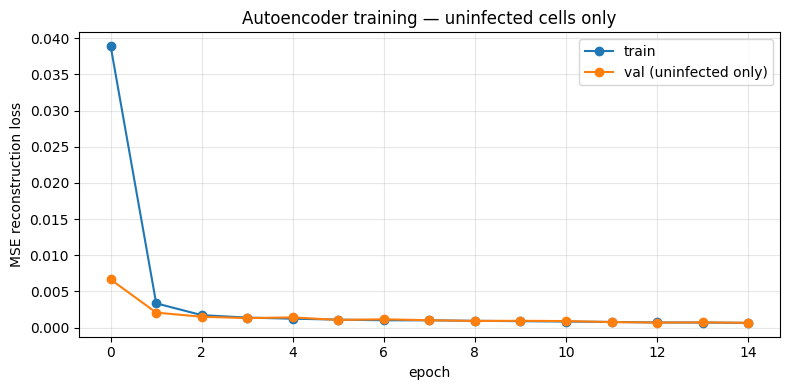

In [3]:
def run_epoch_ae(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(mode=is_train)
    total_loss, total_samples = 0.0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for xb, _ in loader:   # labels are ignored entirely — the input IS the target
            xb = xb.to(DEVICE)
            recon, _ = model(xb)
            loss = F.mse_loss(recon, xb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            total_samples += xb.size(0)
    return total_loss / total_samples


torch.manual_seed(RNG_SEED)
model_ae = ConvAutoencoder(latent_dim=128).to(DEVICE)
optimizer = torch.optim.Adam(model_ae.parameters(), lr=1e-3)

MAX_EPOCHS = 15
history_ae = {"train_loss": [], "val_loss": []}
for epoch in range(1, MAX_EPOCHS + 1):
    tl = run_epoch_ae(model_ae, train_loader_ae, optimizer)
    vl = run_epoch_ae(model_ae, val_loader_ae, optimizer=None)
    history_ae["train_loss"].append(tl); history_ae["val_loss"].append(vl)
    print(f"epoch {epoch:>2d}  |  train MSE {tl:.5f}  |  val MSE {vl:.5f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_ae["train_loss"], label="train", marker="o")
ax.plot(history_ae["val_loss"], label="val (uninfected only)", marker="o")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE reconstruction loss")
ax.set_title("Autoencoder training — uninfected cells only"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 4.1 Look at the reconstructions

Always look at your data — and your model's output. Reconstructions should look like recognisable, if slightly blurred, versions of the uninfected input cells.

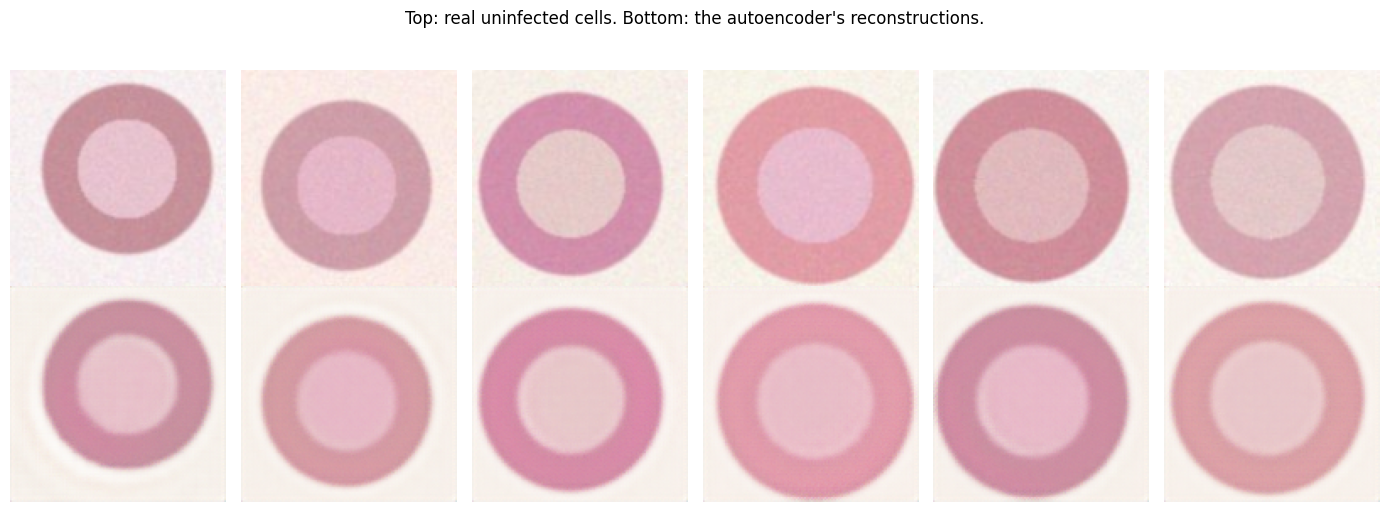

In [4]:
model_ae.eval()
sample_x, _ = next(iter(val_loader_ae))
sample_x = sample_x[:6].to(DEVICE)
with torch.no_grad():
    recon_x, _ = model_ae(sample_x)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    axes[0, i].imshow(sample_x[i].cpu().permute(1, 2, 0)); axes[0, i].axis("off")
    axes[1, i].imshow(recon_x[i].cpu().permute(1, 2, 0)); axes[1, i].axis("off")
axes[0, 0].set_ylabel("original", fontsize=11)
axes[1, 0].set_ylabel("reconstructed", fontsize=11)
plt.suptitle("Top: real uninfected cells. Bottom: the autoencoder's reconstructions.", y=1.02)
plt.tight_layout(); plt.show()

## 5. Anomaly detection — reconstruction error as a signal

Now the real test. Run the trained autoencoder on the **full test set** — both classes this time — and look at reconstruction error per image. The prediction: **parasitized cells should reconstruct noticeably worse**, because the model never learned what a dark parasite spot looks like; it can only draw on what it learned from healthy cells, which don't have one.

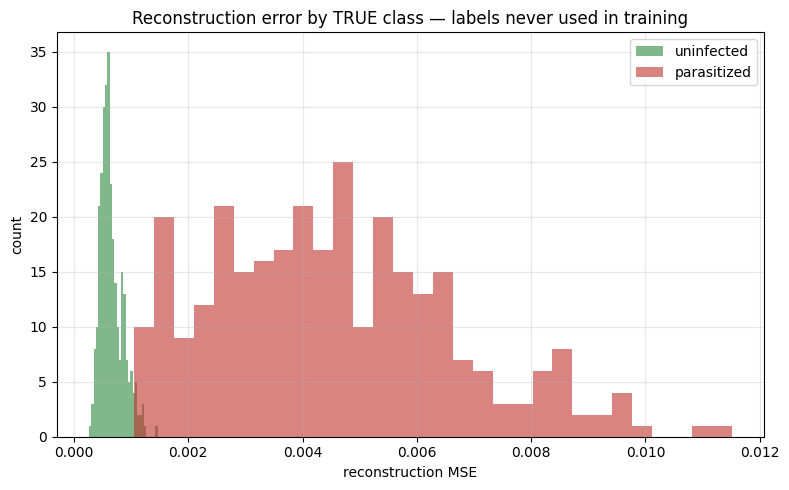

Mean reconstruction MSE, uninfected:  0.00065
Mean reconstruction MSE, parasitized: 0.00454


In [5]:
test_loader_full = DataLoader(test_full, batch_size=BATCH_SIZE, shuffle=False)

model_ae.eval()
errors, labels = [], []
with torch.no_grad():
    for xb, yb in test_loader_full:
        xb = xb.to(DEVICE)
        recon, _ = model_ae(xb)
        per_image_mse = ((recon - xb) ** 2).mean(dim=(1, 2, 3))
        errors.extend(per_image_mse.cpu().numpy().tolist())
        labels.extend(yb.numpy().tolist())
errors = np.array(errors)
labels = np.array(labels)   # 0 = parasitized, 1 = uninfected (ImageFolder's alphabetical order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(errors[labels == uninfected_idx], bins=30, alpha=0.6, label="uninfected", color="#2b8a3e")
ax.hist(errors[labels == parasitized_idx], bins=30, alpha=0.6, label="parasitized", color="#c0322b")
ax.set_xlabel("reconstruction MSE"); ax.set_ylabel("count")
ax.set_title("Reconstruction error by TRUE class — labels never used in training")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Mean reconstruction MSE, uninfected:  {errors[labels == uninfected_idx].mean():.5f}")
print(f"Mean reconstruction MSE, parasitized: {errors[labels == parasitized_idx].mean():.5f}")

### 5.1 Turning this into a classifier — and why ROC is valid here

We now have a single number per image (reconstruction error) and two true classes. Sweeping a threshold on that number to call each image "anomalous" (parasitized) or "normal" (uninfected) makes this a genuine **binary classifier** — treat "anomalous" as the positive class, exactly as Lab 2 treated "malignant" as the positive class for the breast cancer screening task.

**This is also the case Lab 8 told you to watch for.** Lab 8 spent a whole section explaining why ROC curves are *invalid* for object detection, because "true negative" has no sensible definition when a model can propose boxes anywhere in continuous space. Here, every test image has exactly one true label and one predicted label — true negatives (uninfected cells correctly called normal) are perfectly well-defined. **ROC is the right tool for this problem, unlike Lab 8's.** The two-terms-look-similar-but-aren't-the-same distinction is the whole point.

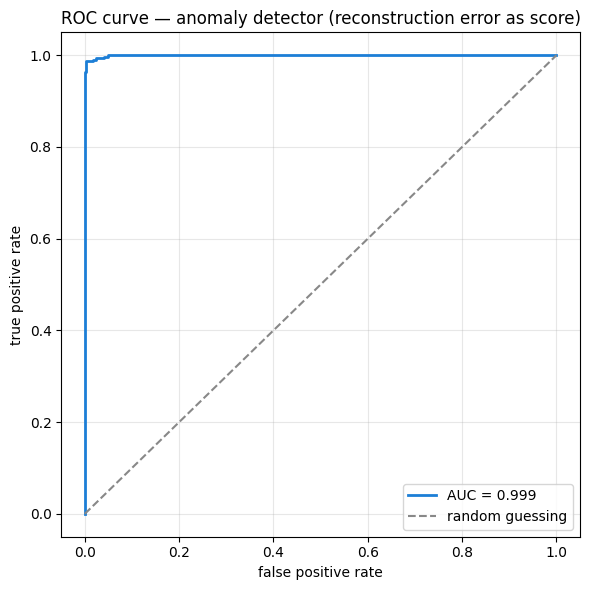

ROC-AUC: 0.9995
(0.5 = no better than chance, 1.0 = perfect separation)


In [6]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

# Positive class = anomaly = parasitized. Score = reconstruction error (higher = more anomalous).
y_true = (labels == parasitized_idx).astype(int)
y_score = errors

auc = roc_auc_score(y_true, y_score)
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#1c7ed6", linewidth=2, label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], color="#888888", linestyle="--", label="random guessing")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC curve — anomaly detector (reconstruction error as score)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"ROC-AUC: {auc:.4f}")
print("(0.5 = no better than chance, 1.0 = perfect separation)")

An AUC well above 0.5 means the autoencoder learned a genuinely useful anomaly signal — from *zero* parasitized examples, using only a reconstruction loss. That's the whole point of unsupervised anomaly detection: it can flag problems it was never specifically shown, which is precisely what you want for the "something unusual, not sure what yet" case a fixed-class classifier like Lab 5's `CellCNN` cannot handle by design (`CellCNN` can only ever say "parasitized" or "uninfected" — never "I don't recognise this").

## 6. Can the autoencoder generate new cells? (Probably not well — here's why)

The decoder can turn *any* latent vector into an image. What if we feed it random noise instead of a real image's encoding?

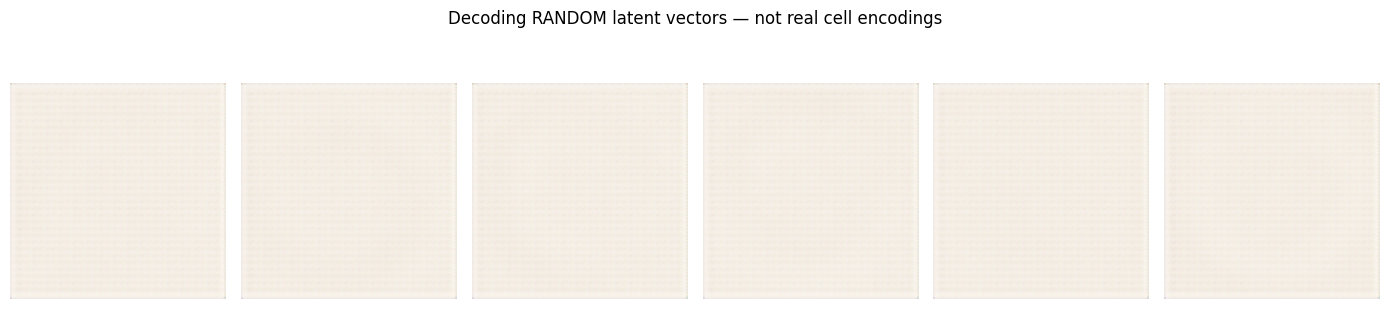

In [7]:
model_ae.eval()
with torch.no_grad():
    random_z = torch.randn(6, model_ae.latent_dim).to(DEVICE)
    generated = model_ae.decode(random_z)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i in range(6):
    axes[i].imshow(generated[i].cpu().permute(1, 2, 0)); axes[i].axis("off")
plt.suptitle("Decoding RANDOM latent vectors — not real cell encodings", y=1.05)
plt.tight_layout(); plt.show()

These usually look like smudges, not cells. **Nothing in the autoencoder's training ever asked the latent space to be smoothly decodable *everywhere*** — it only ever had to be decodable at the exact points where real encoded images happen to land. Random noise almost certainly lands somewhere else in that 128-dimensional space, somewhere the decoder was never trained to make sense of. (A **variational autoencoder** fixes exactly this, by explicitly regularising the latent space during training to be smooth and Gaussian-shaped — out of scope today, but worth knowing the fix exists and *why* it's needed, having just seen the problem first-hand.)

This is the practical motivation for Sections 7 onward: if you actually want a model whose job is *generating* convincing new images, autoencoders are the wrong tool. GANs were built to solve exactly this.

## 7. Adversarial training

A GAN trains **two networks with opposing objectives**, simultaneously:

- The **generator** `G` takes random noise `z` and tries to produce an image realistic enough to fool the discriminator.
- The **discriminator** `D` takes an image (real or generated) and tries to correctly say which it is.

Formally, this is a minimax game: `G` tries to *minimise* `D`'s ability to tell real from fake; `D` tries to *maximise* it. Unlike every previous loss in this module, there is no fixed target either network is converging toward — each network's "correct answer" keeps shifting as the *other* network improves. This is precisely why GAN training is famously less stable than a standard supervised loss: there is no guarantee both networks improve together, or that either one converges at all.

In practice, training alternates, batch by batch:

1. **Train `D`** on a batch of real images (label 1) and a batch of `G`'s current fakes (label 0) — a completely standard binary classification step, using `BCEWithLogitsLoss` exactly as Lab 2 did.
2. **Train `G`** by generating a fresh batch of fakes, running them through `D`, and computing the same `BCEWithLogitsLoss` but with the labels **flipped to 1** — `G`'s loss is "how far is `D` from believing these are real", so `G`'s gradient pushes its outputs to look *more* real.

## 8. Data — MNIST, for speed and reliability

We switch datasets for the GAN half of this lab. GANs are notoriously slow and unstable to train well from scratch — MNIST is small, simple, and well-behaved enough to get recognisable, if imperfect, results within a lab session, which a photographic dataset like CIFAR-10 usually is not without far more epochs and tuning than we have time for today.

In [8]:
gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),   # scale to [-1, 1], to match the generator's Tanh output
])
mnist_train = datasets.MNIST(root="data", train=True, download=True, transform=gan_transform)
gan_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
print(f"MNIST training images: {len(mnist_train)}")

LATENT_DIM = 100

MNIST training images: 60000


## 9. Building the DCGAN

The DCGAN recipe (Radford et al., 2015): the generator upsamples noise via transposed convolutions; the discriminator downsamples images via strided convolutions — the same building blocks Lab 3 used, just running in reverse for the generator.

In [9]:
class Generator(nn.Module):
    """Noise (latent_dim,) -> a 28x28 grayscale image, via 7 -> 14 -> 28 upsampling."""

    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.project = nn.Linear(latent_dim, 128 * 7 * 7)
        self.net = nn.Sequential(
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),  # 7 -> 14
            nn.ConvTranspose2d(64, 1, 4, 2, 1), nn.Tanh(),                                     # 14 -> 28, [-1,1]
        )

    def forward(self, z):
        h = self.project(z).view(-1, 128, 7, 7)
        return self.net(h)


class Discriminator(nn.Module):
    """A 28x28 grayscale image -> one real/fake logit, via 28 -> 14 -> 7 downsampling."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),                        # 28 -> 14
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),  # 14 -> 7
        )
        self.head = nn.Linear(128 * 7 * 7, 1)

    def forward(self, x):
        h = self.net(x)
        h = torch.flatten(h, start_dim=1)
        return self.head(h)   # raw logit — BCEWithLogitsLoss applies the sigmoid internally


torch.manual_seed(RNG_SEED)
generator = Generator().to(DEVICE)
discriminator = Discriminator().to(DEVICE)
print(f"Generator parameters:     {sum(p.numel() for p in generator.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}")

with torch.no_grad():
    test_z = torch.randn(2, LATENT_DIM).to(DEVICE)
    test_img = generator(test_z)
    test_logit = discriminator(test_img)
print(f"Generator output shape:     {tuple(test_img.shape)}")
print(f"Discriminator output shape: {tuple(test_logit.shape)}")

Generator parameters:     766,017
Discriminator parameters: 138,817
Generator output shape:     (2, 1, 28, 28)
Discriminator output shape: (2, 1)


## 10. Training the GAN

> ⏱ **Time estimate.** On a 3090/4090/5090, expect roughly 20-40 seconds per epoch at this batch size; 20 epochs should comfortably fit in a lab session. Watch the sample grids every few epochs — they tell you far more about whether training is going well than the loss numbers alone do (Section 11 explains why).

epoch  1  |  G loss 3.7996  |  D loss 0.2873


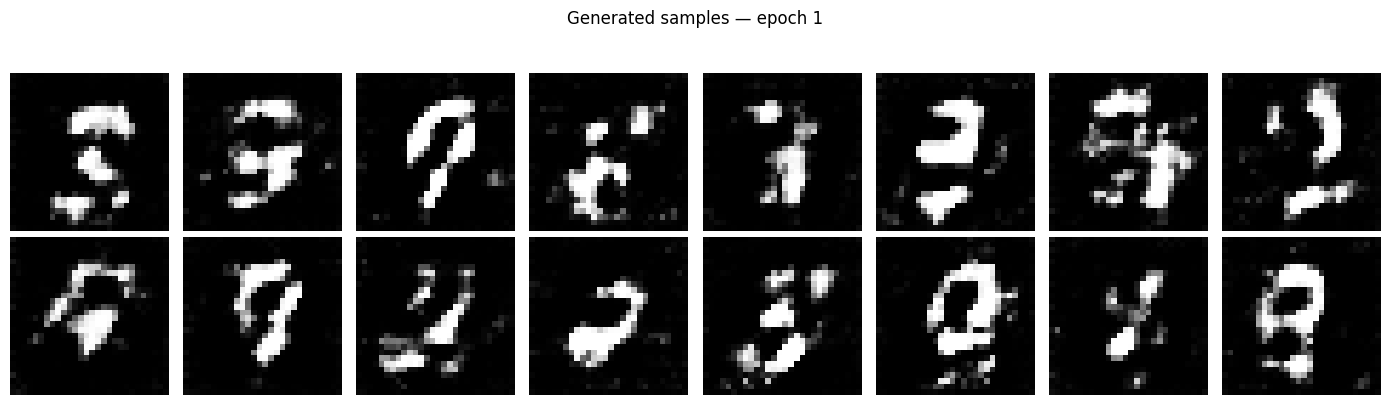

epoch  2  |  G loss 2.2717  |  D loss 0.3631
epoch  3  |  G loss 2.8133  |  D loss 0.2567
epoch  4  |  G loss 2.8737  |  D loss 0.2599
epoch  5  |  G loss 2.7540  |  D loss 0.3200


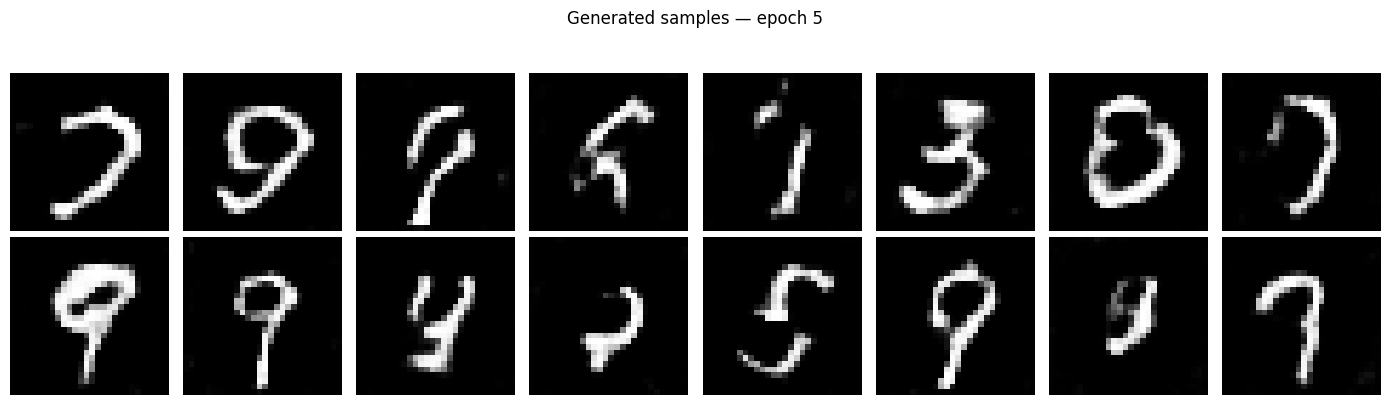

epoch  6  |  G loss 2.6172  |  D loss 0.3508
epoch  7  |  G loss 2.5177  |  D loss 0.3892
epoch  8  |  G loss 2.5275  |  D loss 0.3834
epoch  9  |  G loss 2.5328  |  D loss 0.3841
epoch 10  |  G loss 2.5564  |  D loss 0.3920


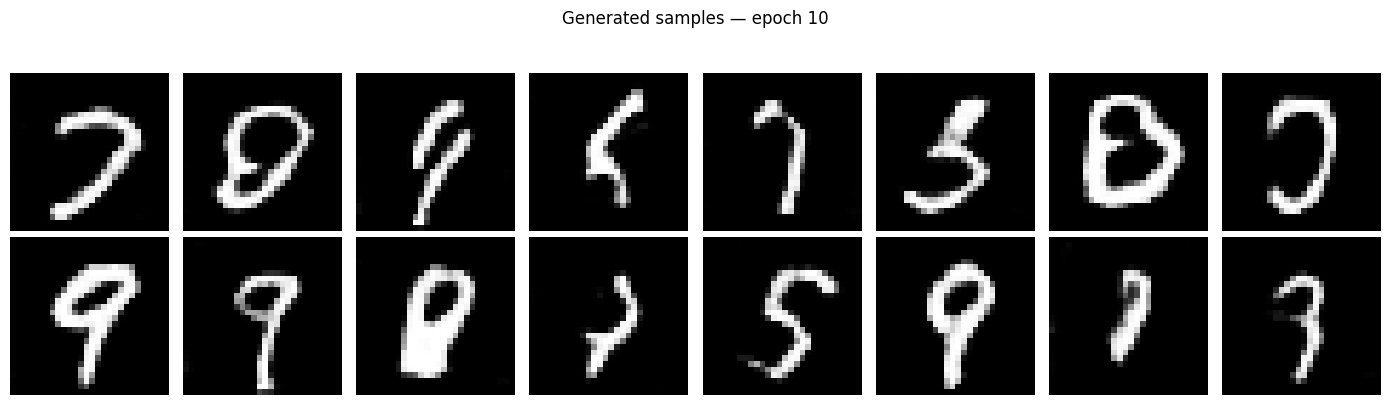

epoch 11  |  G loss 2.4716  |  D loss 0.4352
epoch 12  |  G loss 2.5767  |  D loss 0.4033
epoch 13  |  G loss 2.6021  |  D loss 0.4187
epoch 14  |  G loss 2.6274  |  D loss 0.3822
epoch 15  |  G loss 2.6705  |  D loss 0.3986


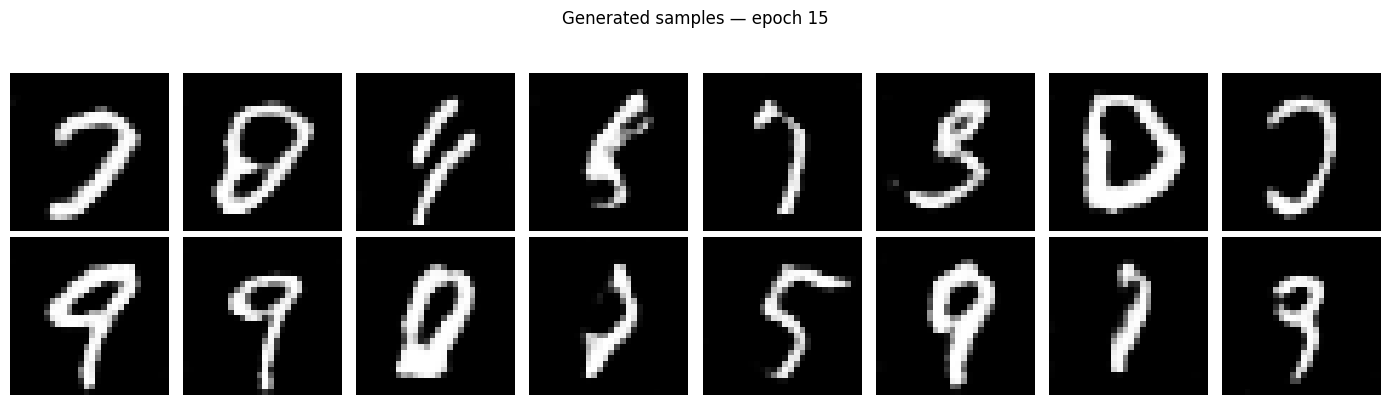

epoch 16  |  G loss 2.7070  |  D loss 0.3858
epoch 17  |  G loss 2.7346  |  D loss 0.3918
epoch 18  |  G loss 2.7386  |  D loss 0.3916
epoch 19  |  G loss 2.7586  |  D loss 0.3886
epoch 20  |  G loss 2.7268  |  D loss 0.4426


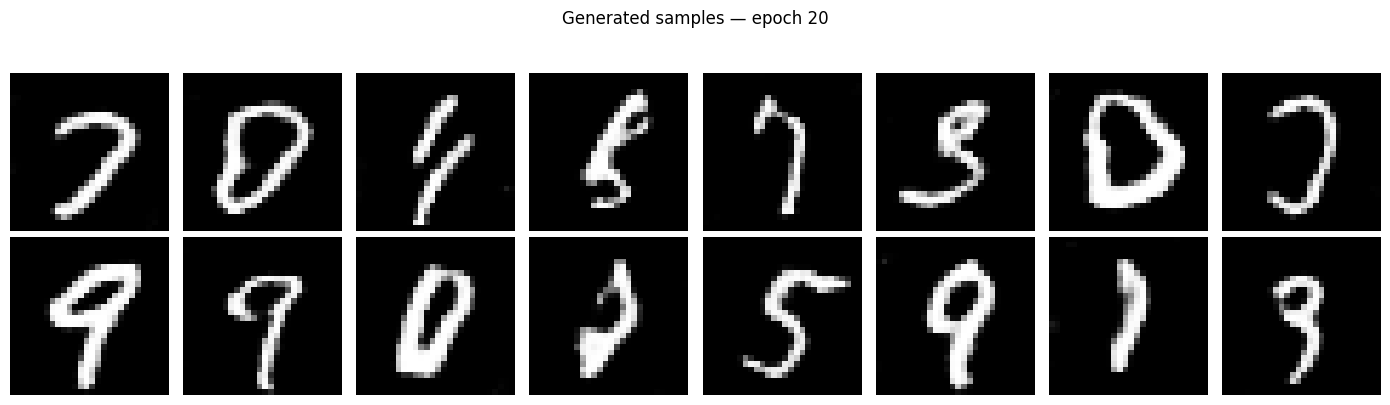

In [10]:
criterion = nn.BCEWithLogitsLoss()
opt_g = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

FIXED_NOISE = torch.randn(16, LATENT_DIM, device=DEVICE)   # same noise every checkpoint, so we can watch it improve

def show_samples(epoch):
    generator.eval()
    with torch.no_grad():
        samples = generator(FIXED_NOISE).cpu()
    samples = (samples + 1) / 2   # undo the Tanh [-1,1] scaling for display
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for ax, img in zip(axes.flat, samples):
        ax.imshow(img.squeeze(0), cmap="gray"); ax.axis("off")
    plt.suptitle(f"Generated samples — epoch {epoch}", y=1.02)
    plt.tight_layout(); plt.show()
    generator.train()


MAX_EPOCHS = 20
history_gan = {"g_loss": [], "d_loss": []}

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_g_loss, epoch_d_loss, n_batches = 0.0, 0.0, 0
    for real_imgs, _ in gan_loader:
        real_imgs = real_imgs.to(DEVICE)
        bs = real_imgs.size(0)
        real_labels = torch.ones(bs, 1, device=DEVICE)
        fake_labels = torch.zeros(bs, 1, device=DEVICE)

        # --- Train discriminator: real should score ~1, fake should score ~0 ---
        opt_d.zero_grad()
        d_real = discriminator(real_imgs)
        loss_d_real = criterion(d_real, real_labels)

        z = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = generator(z)
        d_fake = discriminator(fake_imgs.detach())   # detach: don't backprop into G here
        loss_d_fake = criterion(d_fake, fake_labels)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_d.step()

        # --- Train generator: wants the discriminator to call its fakes "real" ---
        opt_g.zero_grad()
        d_on_fake = discriminator(fake_imgs)
        loss_g = criterion(d_on_fake, real_labels)   # flipped labels — this is the adversarial trick
        loss_g.backward()
        opt_g.step()

        epoch_g_loss += loss_g.item(); epoch_d_loss += loss_d.item(); n_batches += 1

    history_gan["g_loss"].append(epoch_g_loss / n_batches)
    history_gan["d_loss"].append(epoch_d_loss / n_batches)
    print(f"epoch {epoch:>2d}  |  G loss {history_gan['g_loss'][-1]:.4f}  |  D loss {history_gan['d_loss'][-1]:.4f}")

    if epoch == 1 or epoch % 5 == 0 or epoch == MAX_EPOCHS:
        show_samples(epoch)

## 11. Diagnosing GAN training

Plot the loss curves and look for two classic pathologies.

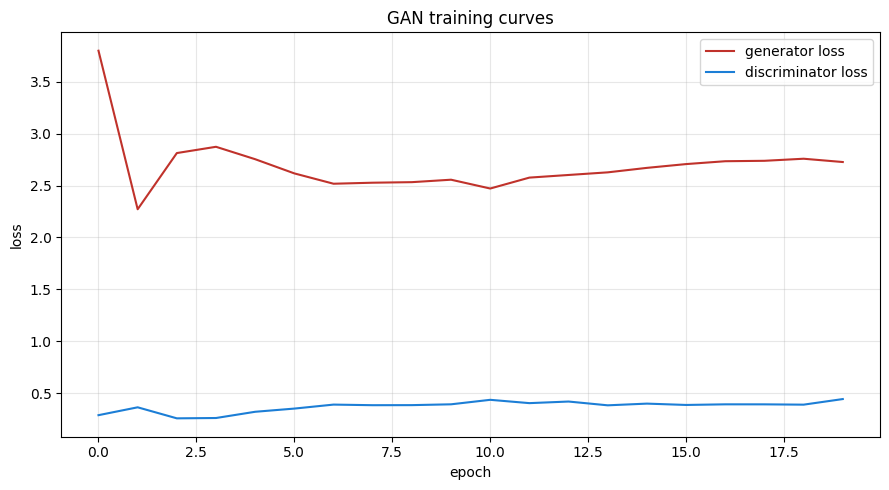

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history_gan["g_loss"], label="generator loss", color="#c0322b")
ax.plot(history_gan["d_loss"], label="discriminator loss", color="#1c7ed6")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.set_title("GAN training curves")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**What to look for — and why loss curves alone can mislead you here:**

- **Discriminator loss collapsing toward 0.** If `D` gets too good too fast, it can perfectly separate real from fake, which means the gradient it hands back to `G` stops being useful — `G` gets no meaningful signal on *how* to improve, because `D` is simply always right regardless of what `G` does. Unlike a supervised loss trending to zero (which is good news, e.g. Lab 3's training loss), a GAN discriminator loss near zero *for both real and fake batches simultaneously* is often a bad sign.
- **Mode collapse.** Look at the sample grids from Section 10, not just the loss numbers — a generator that has found *one or two* digit shapes that reliably fool the discriminator has no incentive to produce anything else, and loss curves alone can look perfectly reasonable while every generated image looks nearly identical. This is precisely why the module keeps insisting: **always look at the actual output, not just the aggregate number.**

**Neither loss curve, on its own, tells you whether training is going well** — this is the single biggest practical difference from every previous training loop in this module, where a falling loss reliably meant "improving." Sample grids are not optional here; they're the primary diagnostic.

---

## 12. Exercise 1 — choosing an anomaly-detection threshold

Section 5 computed a ROC-AUC but never actually picked an operating threshold. Do that properly now, using the same asymmetric-cost reasoning as Lab 2's cancer screening and Lab 8's confidence-threshold exercises.

1. Using `precision_recall_curve` (already imported in Section 5) on `y_true`/`y_score`, plot precision and recall against threshold.
2. Suppose this is a **screening** tool: missing a parasitized cell (false negative) is far worse than flagging a healthy one for a human to double-check (false positive). Pick a threshold that reflects that priority, and state the precision and recall you'd get at it.
3. Now suppose it's used to automatically discard cells with no human review at all — false positives (discarding a genuinely healthy cell) become costly too. Pick a different threshold for that scenario, and justify the change in 2-3 sentences.

In [ ]:
# Your code for Exercise 1 here.

*Your two thresholds and justification:*

## 13. Exercise 2 — GAN training diagnostics

1. Identify, from Section 11's loss curves, whether there is any point where the discriminator loss drops sharply while generator loss rises sharply (a sign of `D` "winning"). If you see this, does sample quality around that epoch (from the saved grids) look worse than a few epochs earlier or later?
2. Compute a simple diversity measure for a batch of 64 freshly generated samples: flatten each image to a vector and compute the mean pairwise Euclidean distance across all pairs. Compute the same measure for 64 real MNIST images. Is the generated batch's diversity noticeably lower than the real batch's — a quantitative sign of partial mode collapse — or roughly comparable?
3. Write 3-4 sentences on what you'd try first if you saw clear mode collapse in your own run (consider: lowering the discriminator's learning rate relative to the generator's, adding noise to discriminator inputs, or simply training for fewer epochs before it sets in).

In [ ]:
# Your code for Exercise 2 here.

*Your diagnostics and findings:*

## 14. Exercise 3 — open-ended (pick one)

**Option A — Latent space interpolation.** Sample two random noise vectors `z1` and `z2`. Generate images at 8 evenly-spaced interpolation points between them (`z = (1-t)*z1 + t*z2` for `t` in `[0, 1]`). Display the sequence. Does the generator produce a smooth, plausible morph between the two digits, or does it pass through implausible intermediate images? What does your answer suggest about how smooth/well-structured the generator's learned mapping from noise to image actually is?

**Option B — A simple class-conditional GAN.** Modify the generator to take a one-hot-encoded digit label concatenated with the noise vector as input (project `latent_dim + 10` instead of `latent_dim`), and modify the discriminator to also receive the label (e.g. as extra input channels, broadcast to the image's spatial size). Retrain. Can you now request a specific digit and reliably get it?

**Option C — Is the autoencoder earning its complexity?** Build the simplest possible anomaly-detection baseline you can think of that does *not* need training a neural network at all (e.g. threshold on the count of very-dark pixels per cell image, or mean pixel intensity). Compute its ROC-AUC on the same test set as Section 5. Compare against the autoencoder's AUC. Was the autoencoder worth building, or does a trivial baseline get most of the way there? This is the same "check a naive baseline before trusting the fancy model" discipline good practitioners apply everywhere.

In [ ]:
# Your code for Exercise 3 (Option A, B, or C) here.

*Which option did you pick, and what did you find?*

---

## 15. Reflection questions

**Q1.** Explain, in your own words, why forcing information through a narrow bottleneck gives an autoencoder a useful training signal even though no labels are involved anywhere.

**Q2.** Your anomaly detector never saw a single parasitized cell during training. Explain mechanically *why* reconstruction error is higher for parasitized cells regardless — what specifically does the model fail to reconstruct, and why?

**Q3.** Contrast the training signal of a GAN (two networks with opposing objectives) against every other model trained in this module (a single, fixed loss function being minimised directly). Name one specific instability this introduces that a model like Lab 3's CNN never has to worry about.

**Q4.** Referring back to Lab 8: explain why ROC curves are invalid for object detection but valid for today's anomaly-detection evaluation. What is the crucial structural difference between the two problems that makes true negatives well-defined in one case and not the other?

**Q5.** A hospital wants an automatic "flag anything unusual" system for blood smear images, rather than a fixed parasitized/uninfected classifier like Lab 5's `CellCNN`. Would you recommend today's anomaly-detection autoencoder or Lab 5's supervised classifier? Under what specific circumstance is the anomaly-detection approach *more* valuable than a fixed-class classifier, regardless of which currently scores higher on this particular test set?

*Your answers:*

**A1.**

**A2.**

**A3.**

**A4.**

**A5.**

---

## What's next

Across fourteen labs you have gone from implementing a perceptron by hand to training and honestly evaluating object detectors, segmenting images with a foundation model, auditing a trained network's own reasoning, measuring the inductive-bias trade-off between CNNs and Transformers, opening up a multi-modal embedding space, and — today — building models that generate rather than merely discriminate. The specific architectures here will keep changing; the module's most durable habits won't: **look at your actual data and your actual output, not just the aggregate number (every lab); measure honestly, with a genuinely independent test set (Lab 8); understand what a model assumes before you trust it (Labs 1, 9, 11, 12); and check a simple baseline before reaching for a complicated one (today's Exercise 3, and really, always).**

Before leaving today, make sure:

- [ ] You trained the autoencoder on uninfected cells only and measured its ROC-AUC as an anomaly detector on both classes
- [ ] You trained the DCGAN and watched sample quality improve across epochs
- [ ] You can explain, from your own loss curves and sample grids, whether your GAN run showed any sign of mode collapse or discriminator dominance
- [ ] You completed Exercises 1, 2, and 3
- [ ] You answered the reflection questions
- [ ] Your notebook runs **top to bottom without errors**

One generative paradigm remains. The GAN above produces an image in a single forward pass, adversarially trained — Lab 15 takes the opposite approach: a single, stable, non-adversarial loss, but *hundreds* of small iterative refinement steps instead of one. Same goal, from-first-principles-then-a-pretrained-foundation-model structure as today, an entirely different mechanism: diffusion models, and how a model like Stable Diffusion turns text into a photograph.